In [17]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from pydantic import BaseModel
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
import os
from dotenv import load_dotenv
from langgraph.checkpoint.memory import  MemorySaver

In [18]:
load_dotenv()

True

In [19]:
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

In [20]:
model  = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    api_key=GROQ_API_KEY)
model

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000023B6739E190>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000023B673B4F10>, model_name='qwen/qwen3-32b', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [21]:
class ChatState(TypedDict):
    message: Annotated[list[BaseMessage], add_messages]

In [22]:
def chat_node(state: ChatState):
    message = state['message']
    response = model.invoke(message)
    return {'message': [response]}

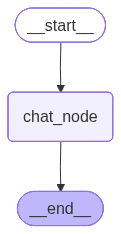

In [24]:
## memory saver

checkpoint = MemorySaver()

graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node',END)

workflow = graph.compile(checkpointer = checkpoint)
workflow

In [26]:
# initial_status = {
#     'message': [HumanMessage(content='What is OOPS?')]
# }

# response = workflow.invoke(initial_status)
# print(response['message'][-1].content)

In [30]:
thread_id = '1'

while True:
    user_input = input('Type here..')
    print(user_input)
    if user_input.strip().lower() in ['exit','quit','bye']:
        break

    config = {'configurable': {'thread_id' : thread_id}}

    response = workflow.invoke({
        'message': [HumanMessage(content=user_input)]
    }, config=config)
    print('AI:' , response['message'][-1].content)

what is my name
AI: <think>
Okay, the user keeps asking "what is my name" repeatedly. Let me check the history. The user initially introduced themselves as Rohan. I confirmed their name each time they asked. Now they're asking again. Maybe they're testing if I remember, or they're having trouble with the interface. I should keep the response consistent and friendly. Let me make sure to reaffirm their name and offer help again. No need to change the response since the information hasn't changed. Just keep it simple and positive.
</think>

Your name is **Rohan**! 😊 Let me know how I can assist you.
what is gen ai. give me in 20 words
AI: <think>
Okay, the user asked for a 20-word explanation of Gen AI. Let me start by recalling the previous interaction where they wanted a 50-word answer. Now they need it shorter.

First, I need to condense the key points: Generative AI creates content like text, images, etc., using machine learning models trained on large datasets. It generates new outpu

In [32]:
thread_id = '2'

while True:
    user_input = input('Type here..')
    print(user_input)
    if user_input.strip().lower() in ['exit','quit','bye']:
        break

    config = {'configurable': {'thread_id' : thread_id}}

    response = workflow.invoke({
        'message': [HumanMessage(content=user_input)]
    }, config=config)
    print('AI:' , response['message'][-1].content)

my name is deepak
AI: <think>
Okay, the user just told me their name is Deepak. Let me check the conversation history.

Earlier, they asked, "what is my name" and I explained that I don't have access to their personal info. Now they're providing their name. I should acknowledge their name and maybe use it in the response to make it personal. 

They might want to continue the conversation with their name being recognized. I should respond warmly and invite them to ask more questions. Let me make sure to use their name in the response and keep the tone friendly. Also, check if there's any other context I need to consider. No, looks straightforward. Just confirm their name and offer further help.
</think>

Nice to meet you, Deepak! 😊 How can I assist you today?
what is my name
AI: <think>
Okay, the user just asked, "what is my name" again. Let me check the conversation history.

Earlier, the user asked the same question, and I told them I don't have access to their name unless they share 

In [33]:
thread_id = '1'

while True:
    user_input = input('Type here..')
    print(user_input)
    if user_input.strip().lower() in ['exit','quit','bye']:
        break

    config = {'configurable': {'thread_id' : thread_id}}

    response = workflow.invoke({
        'message': [HumanMessage(content=user_input)]
    }, config=config)
    print('AI:' , response['message'][-1].content)

what is my nake
AI: <think>
Okay, the user asked, "what is my nake." First, I need to check if there's a typo. "Nake" doesn't make sense. The user has previously asked about their name, which is Rohan. Maybe they meant "name" again but mistyped it. Alternatively, "nake" could be a misspelling of "naked," but that seems unlikely here.

Looking at the history, the user has repeatedly asked for their name, so it's possible they're testing if I remember or if there's a mistake. Since the correct name is Rohan, and the user has confirmed it before, I should address the typo politely. I should correct the typo, confirm their name again, and offer assistance. Also, maybe they want to know something else related to "nake," but without more context, it's safer to stick to the name. I'll respond by pointing out the typo, reiterating their name, and asking if they need help with anything else. Keeping the tone friendly and helpful is key here.
</think>

It looks like you might have meant "name" (

In [34]:
workflow.get_state(config=config)

StateSnapshot(values={'message': [HumanMessage(content='MY name is rohan', additional_kwargs={}, response_metadata={}, id='aeaff6c2-5d0c-47e3-a99a-164918ec04cd'), AIMessage(content="<think>\nOkay, the user mentioned their name is Rohan. I should acknowledge that and make sure to use it correctly. Let me check if there's any specific context or previous interactions I need to consider. Since this is the first message, I'll just greet them by name and offer assistance. I need to keep the response friendly and open-ended to encourage them to ask questions or share what they need help with. Also, make sure the spelling of their name is correct. Alright, that should cover it.\n</think>\n\nHello, Rohan! How can I assist you today? Feel free to ask any questions or let me know if you need help with something specific. 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 138, 'prompt_tokens': 13, 'total_tokens': 151, 'completion_time': 0.291549906, 'completion_toke